In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [3]:
df.shape

(920, 16)

In [4]:
df_clean = df.copy()

In [5]:
df_clean.loc[df_clean["chol"]== 0, "chol"] = np.nan

In [6]:
df_clean.loc[df_clean["trestbps"] == 0, "trestbps"] = np.nan

Data cleaning started by converting clinically impossible values into missing values.

- Cholesterol values equal to 0 were treated as missing because a cholesterol level of zero is physiologically implausible.
- Resting blood pressure values equal to 0 were also treated as missing for the same reason.

These values were converted to NaN to ensure that subsequent imputation methods treat them as missing observations rather than valid measurements.

In [7]:
df_clean.isna().sum()

age                 0
sex                 0
cp                  0
trestbps           60
chol              202
fbs                90
restecg             2
thalach            55
exang              55
oldpeak            62
slope             309
ca                611
thal              486
target              0
country             0
clinical_index     55
dtype: int64

In [8]:
missing_pct = (df_clean.isna().sum() / len(df_clean) * 100).sort_values(ascending=False)
missing_pct

ca                66.413043
thal              52.826087
slope             33.586957
chol              21.956522
fbs                9.782609
oldpeak            6.739130
trestbps           6.521739
thalach            5.978261
exang              5.978261
clinical_index     5.978261
restecg            0.217391
cp                 0.000000
sex                0.000000
age                0.000000
target             0.000000
country            0.000000
dtype: float64

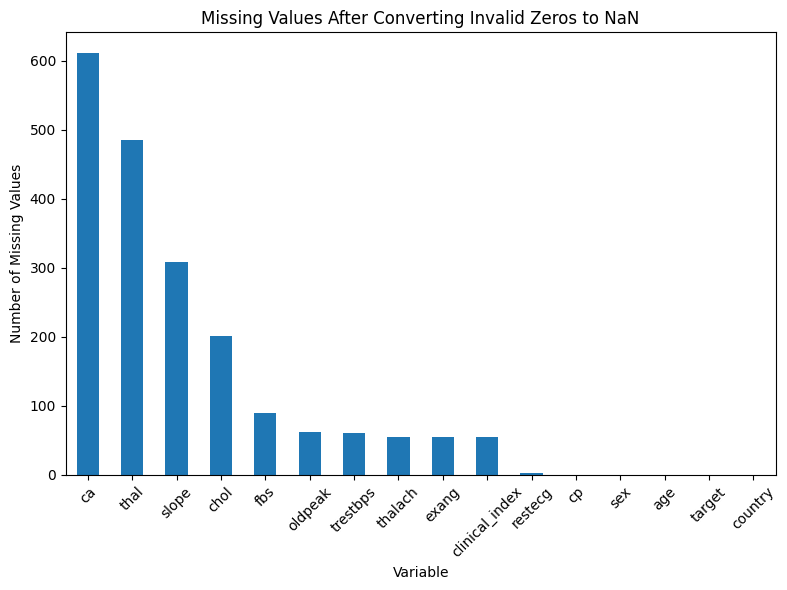

In [9]:
missing_counts = df_clean.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
missing_counts.plot(kind="bar")

plt.title("Missing Values After Converting Invalid Zeros to NaN")
plt.xlabel("Variable")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since only two observations (0.22%) contain missing values in restecg, these rows were removed from the dataset. The impact on sample size and class distribution is negligible.

In [10]:
df_clean = df_clean.dropna( subset= ["restecg"])
df_clean.shape

(918, 16)

In [12]:
df_clean["exang"].value_counts(dropna = False)

exang
0.0    526
1.0    337
NaN     55
Name: count, dtype: int64

In [14]:
df_clean["exang"] = df_clean["exang"].fillna(df_clean["exang"].mode()[0])

In [16]:
df_clean["exang"].value_counts(dropna = False)

exang
0.0    581
1.0    337
Name: count, dtype: int64

In [17]:
df_clean["fbs"].value_counts(dropna=False)

fbs
0.0    691
1.0    138
NaN     89
Name: count, dtype: int64

In [19]:
df_clean["fbs"] = df_clean["fbs"].fillna(df_clean["fbs"].mode()[0])

In [20]:
df_clean["fbs"].value_counts(dropna=False)

fbs
0.0    780
1.0    138
Name: count, dtype: int64

In [21]:
df_clean["thalach"].describe()

count    863.000000
mean     137.528389
std       25.950226
min       60.000000
25%      120.000000
50%      140.000000
75%      157.000000
max      202.000000
Name: thalach, dtype: float64

Since the mean (137.5) and median (140) are very similar, the distribution of thalach appears approximately symmetric. Therefore, mean imputation is considered acceptable for the missing values.

In [22]:
df_clean["thalach"] = df_clean["thalach"].fillna( df_clean["thalach"].mean())

In [23]:
df_clean["thalach"].describe()

count    918.000000
mean     137.528389
std       25.159969
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: thalach, dtype: float64

In [24]:
df_clean["trestbps"].describe()

count    858.000000
mean     132.297203
std       18.546520
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [25]:
df_clean["trestbps"] = df_clean["trestbps"].fillna( df_clean["trestbps"].mean())

In [26]:
df_clean["trestbps"].describe()

count    918.000000
mean     132.297203
std       17.929500
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [27]:
df_clean["oldpeak"].describe()

count    856.000000
mean       0.880607
std        1.091840
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

The distribution of oldpeak appears moderately skewed, with a noticeable difference between the mean (0.88) and median (0.50). Therefore, median imputation was preferred to reduce the influence of extreme values.

In [28]:
df_clean["oldpeak"] = df_clean["oldpeak"].fillna( df_clean["oldpeak"].median())

In [29]:
df_clean["oldpeak"].describe()

count    918.000000
mean       0.854902
std        1.058606
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

In [31]:
df_clean["clinical_index"].describe()

count    863.000000
mean       0.081460
std        2.225077
min       -6.020000
25%       -1.275000
50%        0.310000
75%        1.555000
max        8.680000
Name: clinical_index, dtype: float64

The clinical_index variable exhibits a wide range of values, including both large negative and positive observations. To reduce the influence of extreme values, missing observations were imputed using the median rather than the mean.

In [32]:
df_clean["clinical_index"] = df_clean["clinical_index"].fillna(df_clean["clinical_index"].median())

In [33]:
df_clean["clinical_index"].describe()

count    918.000000
mean       0.095153
std        2.158000
min       -6.020000
25%       -1.150000
50%        0.310000
75%        1.460000
max        8.680000
Name: clinical_index, dtype: float64